<a href="https://colab.research.google.com/github/pleielp/DL-PyTorch/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%EA%B5%90%EA%B3%BC%EC%84%9C/05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05-03

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1)

z = torch.FloatTensor([1, 2, 3])

hypothesis = F.softmax(z, dim=0)
print(hypothesis)
print(hypothesis.sum())

z = torch.rand(3, 5, requires_grad=True)
hypothesis = F.softmax(z, dim=1)
print(hypothesis)
print(hypothesis.sum(dim=1))

y = torch.randint(5, (3,)).long()
print(y)
# 모든 원소가 0의 값을 가진 3 × 5 텐서 생성
y_one_hot = torch.zeros_like(hypothesis)
y_one_hot.scatter_(1, y.unsqueeze(1), 1)
print(y_one_hot)

# cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()
# cost = (y_one_hot * - F.log_softmax(z, dim=1)).sum(dim=1).mean()
# cost = F.nll_loss(F.log_softmax(z, dim=1), y)
cost = F.cross_entropy(z, y)
print(cost)

# 1단계: 클래스로 객체 생성
criterion = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss(reduction='sum')

# 2단계: 생성된 객체 사용
loss = criterion(z, y)
print(loss)

tensor([0.0900, 0.2447, 0.6652])
tensor(1.)
tensor([[0.2645, 0.1639, 0.1855, 0.2585, 0.1277],
        [0.2430, 0.1624, 0.2322, 0.1930, 0.1694],
        [0.2226, 0.1986, 0.2326, 0.1594, 0.1868]], grad_fn=<SoftmaxBackward0>)
tensor([1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)
tensor([0, 2, 1])
tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])
tensor(1.4689, grad_fn=<NllLossBackward0>)
tensor(1.4689, grad_fn=<NllLossBackward0>)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # 가설
    hypothesis = F.softmax(x_train.matmul(W) + b, dim=1)

    # 비용 함수
    cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.622999
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467661
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285072
Epoch 1000/1000 Cost: 0.248155


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # 가설
    z = x_train.matmul(W) + b

    # 비용 함수
    cost = F.cross_entropy(z, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.623000
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467662
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285073
Epoch 1000/1000 Cost: 0.248155


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

# 모델을 선언 및 초기화. 4개의 특성을 가지고 3개의 클래스로 분류. input_dim=4, output_dim=3.
model = nn.Linear(4, 3)

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # 가설
    prediction = model(x_train)

    # 비용 함수
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
      probs = F.softmax(prediction, dim=1)        # 행별 확률
      pred_class = probs.argmax(dim=1)            # 각 샘플의 예측 클래스
      accuracy = (pred_class == y_train).float().mean()
      print('Epoch {:4d}/{} Cost: {:.6f} Acc: {:.2f}'.format(
            epoch, nb_epochs, cost.item(), accuracy.item()
      ))

Epoch    0/1000 Cost: 1.616785 Acc: 0.25
Epoch  100/1000 Cost: 0.658891 Acc: 0.62
Epoch  200/1000 Cost: 0.573443 Acc: 0.62
Epoch  300/1000 Cost: 0.518151 Acc: 0.62
Epoch  400/1000 Cost: 0.473265 Acc: 0.75
Epoch  500/1000 Cost: 0.433516 Acc: 0.75
Epoch  600/1000 Cost: 0.396563 Acc: 0.75
Epoch  700/1000 Cost: 0.360914 Acc: 0.88
Epoch  800/1000 Cost: 0.325392 Acc: 0.88
Epoch  900/1000 Cost: 0.289178 Acc: 0.88
Epoch 1000/1000 Cost: 0.254148 Acc: 1.00


# 05-04

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

USE_CUDA = torch.cuda.is_available() # GPU를 사용가능하면 True, 아니라면 False를 리턴
device = torch.device("cuda" if USE_CUDA else "cpu") # GPU 사용 가능하면 사용하고 아니면 CPU 사용
print("다음 기기로 학습합니다:", device)

# for reproducibility
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

# hyperparameters
training_epochs = 30
batch_size = 100

# MNIST dataset
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

# dataset loader
data_loader = DataLoader(dataset=mnist_train,
                        batch_size=batch_size, # 배치 크기는 100
                        shuffle=True,
                        drop_last=True)

# MNIST data image of shape 28 * 28 = 784
linear = nn.Linear(784, 10, bias=True).to(device)

# 비용 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss().to(device) # 내부적으로 소프트맥스 함수를 포함하고 있음.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.1)

for epoch in range(training_epochs): # 앞서 training_epochs의 값은 15로 지정함.
    sum_cost = 0
    total_batch = len(data_loader)

    # 3등분 출력 지점 계산 (1/3, 2/3, 3/3 위치)
    print_points = [total_batch // 3, (total_batch * 2) // 3, total_batch]

    for i, (X, Y) in enumerate(data_loader, start=1):
        # 배치 크기가 100이므로 아래의 연산에서 X는 (100, 784)의 텐서가 된다.
        X = X.view(-1, 28 * 28).to(device)
        # 레이블은 원-핫 인코딩이 된 상태가 아니라 0 ~ 9의 정수.
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = linear(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        sum_cost += cost

        # 출력 지점에 도달하면 진행도와 누적 평균 cost 출력
        if i in print_points:
            running_avg = sum_cost / i  # 현재까지의 실제 평균
            print('\rEpoch:', '%04d' % (epoch + 1),
                  'Batch: %d/%d' % (i, total_batch),
                  'cost =', '{:.9f}'.format(running_avg),
                  end='',
                  flush=True)
    print()

print('Learning finished')

다음 기기로 학습합니다: cuda
Epoch: 0001 Batch: 600/600 cost = 0.535150588
Epoch: 0002 Batch: 600/600 cost = 0.359577835
Epoch: 0003 Batch: 600/600 cost = 0.331264466
Epoch: 0004 Batch: 600/600 cost = 0.316404492
Epoch: 0005 Batch: 600/600 cost = 0.307107061
Epoch: 0006 Batch: 600/600 cost = 0.300456643
Epoch: 0007 Batch: 600/600 cost = 0.294933140
Epoch: 0008 Batch: 600/600 cost = 0.290956289
Epoch: 0009 Batch: 600/600 cost = 0.287074059
Epoch: 0010 Batch: 600/600 cost = 0.284515887
Epoch: 0011 Batch: 600/600 cost = 0.281914145
Epoch: 0012 Batch: 600/600 cost = 0.279526740
Epoch: 0013 Batch: 600/600 cost = 0.277636468
Epoch: 0014 Batch: 600/600 cost = 0.275874704
Epoch: 0015 Batch: 600/600 cost = 0.274422526
Epoch: 0016 Batch: 600/600 cost = 0.272883356
Epoch: 0017 Batch: 600/600 cost = 0.271629632
Epoch: 0018 Batch: 600/600 cost = 0.270609677
Epoch: 0019 Batch: 600/600 cost = 0.269294947
Epoch: 0020 Batch: 600/600 cost = 0.268277436
Epoch: 0021 Batch: 600/600 cost = 0.267255425
Epoch: 0022 Bat

Accuracy: 0.8704999685287476
Label:  5
Prediction:  3


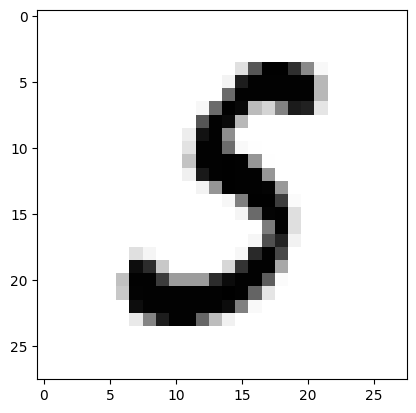

In [36]:
# 테스트 데이터를 사용하여 모델을 테스트한다.
with torch.no_grad(): # torch.no_grad()를 하면 gradient 계산을 수행하지 않는다.
    X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = linear(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

    # MNIST 테스트 데이터에서 무작위로 하나를 뽑아서 예측을 해본다
    r = random.randint(0, len(mnist_test) - 1)
    X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
    Y_single_data = mnist_test.test_labels[r:r + 1].to(device)

    print('Label: ', Y_single_data.item())
    single_prediction = linear(X_single_data)
    print('Prediction: ', torch.argmax(single_prediction, 1).item())

    plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28), cmap='Greys', interpolation='nearest')
    plt.show()

In [37]:
from tqdm import tqdm
import time

for i in tqdm(range(100)):
    time.sleep(0.03)

100%|██████████| 100/100 [00:03<00:00, 32.93it/s]
